In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Epileptor (Seizure Dynamics)

The **Epileptor** is a six-dimensional model of epileptic seizure dynamics. It couples a fast oscillatory subsystem $(x_1, y_1)$, a second (spike-wave) subsystem $(x_2, y_2, g)$, and a **slow permittivity variable** $z$ that acts on a much slower timescale. The slow variable autonomously ramps seizure-like discharges *on* and *off*, reproducing the characteristic onset/offset structure of focal seizures. The excitability parameter $x_0$ sets the epileptogenicity of the node. The recorded signal is the LFP proxy $\text{lfp} = x_2 - x_1$.

**Reference:** Jirsa, Stacey, Quilichini, Ivanov & Bernard (2014), *On the nature of seizure dynamics*, Brain 137(8):2210-2230.

## Build the model

`x0 = -1.6` makes the node epileptogenic (it will seize autonomously). A bounded but long run is needed for the slow `z` variable to drive a full onset/offset cycle.

In [2]:
node = brainmass.EpileptorStep(in_size=1, x0=-1.6)
node

EpileptorStep(
  in_size=(1,),
  out_size=(1,),
  a=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  ),
  b=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(3., dtype=float32)
  ),
  c=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  ),
  d=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(5., dtype=float32)
  ),
  r=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.00035, dtype=float32)
  ),
  x0=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(-1.6, dtype=float32)
  ),
  Iext=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(3.1, dtype=float32)
  ),
  slope=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0., dtype=float32)
  ),
  Iext2=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.45, dtype=float32)
  ),
  tau=Const(
    fit=False,
    t=IdentityT(),
    reg=No

## Run a simulation

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(3000. * u.ms,
              monitors={'lfp': lambda m: m.lfp(), 'z': 'z'})
res['lfp'].shape

(30000, 1)

## Visualize

Top: the LFP proxy shows quiescence, an abrupt seizure onset (fast discharges), and offset. Bottom: the slow permittivity variable `z` is the hidden driver — its slow ramp times the onset and offset.

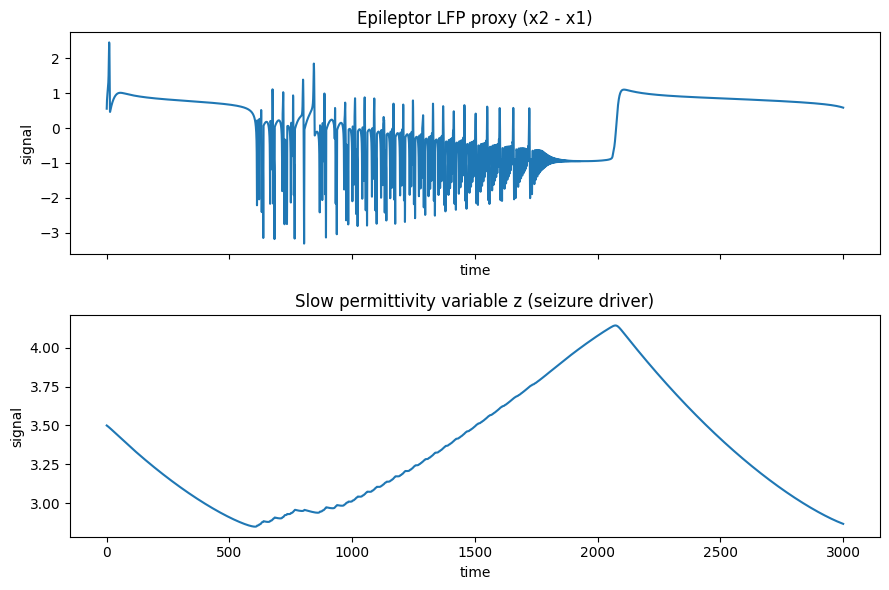

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
brainmass.viz.plot_timeseries(res['lfp'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Epileptor LFP proxy (x2 - x1)')
brainmass.viz.plot_timeseries(res['z'], ts=res['ts'], ax=axes[1])
axes[1].set_title('Slow permittivity variable z (seizure driver)')
plt.tight_layout()
plt.show()

## Try it: vary the epileptogenicity `x0`

`x0` controls whether the node is healthy or epileptogenic. Around `x0 ~ -2.0` lies the boundary: more negative values keep the node healthy (no large excursions), less negative values make it seize. We report the peak of the fast variable `x1` as a simple seizure indicator.

In [5]:
for x0 in [-2.4, -1.8, -1.6]:
    m = brainmass.EpileptorStep(in_size=1, x0=x0)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        3000. * u.ms, monitors={'x1': 'x1'})
    x1max = float(np.max(u.get_magnitude(r['x1'])))
    state = 'seizing' if x1max > 0 else 'healthy'
    print(f'x0 = {x0:.1f}  ->  max(x1) = {x1max:+.3f}  ({state})')

x0 = -2.4  ->  max(x1) = -1.514  (healthy)
x0 = -1.8  ->  max(x1) = +2.016  (seizing)


x0 = -1.6  ->  max(x1) = +2.047  (seizing)
